# Machine Learning - Lab 04
## Tree-Based Machine Learning

| Section | Task |
|---|---|
| 1 | Class Task 1: Build and interpret a Decision Tree |
| 2 | Class Task 2: Decision Tree vs Random Forest |
| 3 | Class Task 3: Tune Gradient Boosting |
| 4 | Class Task 4: XGBoost tuning and model comparison |
| 5 | Class Task 5: XGBoost vs LightGBM |
| 6 | Class Task 6: Mini Kaggle pipeline (Titanic) |
| 7 | Final Class Task: Predicting Smartphone Addiction |

Tasks 1 to 5 use one student dataset (created below). Task 6 needs `titanic_train.csv` and `titanic_test.csv` from Kaggle. The final task needs `smartphone_addiction.csv` (see section 7).

In [1]:
!pip -q install xgboost lightgbm

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Student dataset (used in Tasks 1 to 5)
200 students with `Hours_Studied`, `Attendance`, `Assignments` and the target `Pass` (1 = pass, 0 = fail). The target depends on the three features plus some random noise, so the task is realistic.

In [3]:
np.random.seed(42)
n = 200
students = pd.DataFrame({
    "Hours_Studied": np.random.randint(1, 11, n),
    "Attendance": np.random.randint(40, 101, n),
    "Assignments": np.random.randint(0, 11, n),
})
score = (4 * students["Hours_Studied"] + 0.4 * students["Attendance"]
         + 2 * students["Assignments"] + np.random.normal(0, 8, n))
students["Pass"] = (score > 60).astype(int)

print(students["Pass"].value_counts())
students.head()

Pass
0    107
1     93
Name: count, dtype: int64


,Hours_Studied,Attendance,Assignments,Pass
0,7,61,9,1
1,4,50,2,0
2,8,87,1,1
3,5,55,8,0
4,7,72,7,1


In [4]:
X = students[["Hours_Studied", "Attendance", "Assignments"]]
y = students["Pass"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# helper used in several tasks: returns the four classification scores on the test set
def scores(name, model):
    pred = model.predict(X_test)
    return {"Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred)}

# 1. Class Task 1 - Build and Interpret a Decision Tree

Train a tree with `criterion='gini'` and `'entropy'`, each with `max_depth` 2, 3 and 5.

In [5]:
results = []
for criterion in ["gini", "entropy"]:
    for depth in [2, 3, 5]:
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        tree.fit(X_train, y_train)
        results.append([criterion, depth, tree.score(X_train, y_train), tree.score(X_test, y_test)])

task1 = pd.DataFrame(results, columns=["criterion", "max_depth", "train_accuracy", "test_accuracy"])
task1.round(3)

,criterion,max_depth,train_accuracy,test_accuracy
0,gini,2,0.800,0.75
1,gini,3,0.844,0.75
2,gini,5,0.900,0.75
3,entropy,2,0.800,0.75
4,entropy,3,0.838,0.75
5,entropy,5,0.875,0.75


Tree visualization (entropy, depth 3):

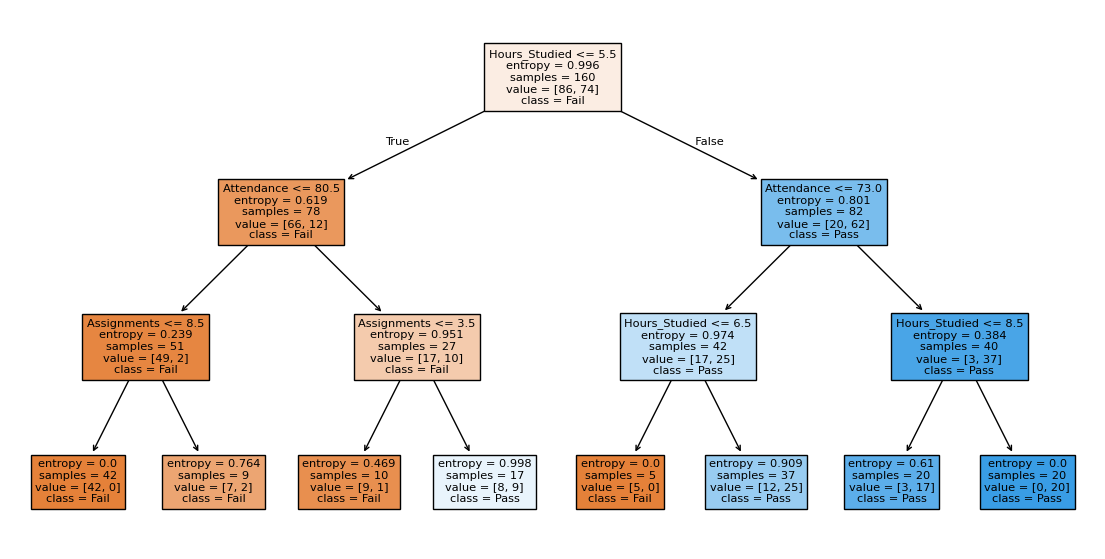

In [6]:
tree3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(14, 7))
plot_tree(tree3, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True)
plt.show()

In [7]:
print("Average train accuracy by depth:")
print(task1.groupby("max_depth")[["train_accuracy", "test_accuracy"]].mean().round(3))
print()
print("Average test accuracy by criterion:")
print(task1.groupby("criterion")["test_accuracy"].mean().round(3))

Average train accuracy by depth:
           train_accuracy  test_accuracy
max_depth                               
2                   0.800           0.75
3                   0.841           0.75
5                   0.888           0.75

Average test accuracy by criterion:
criterion
entropy    0.75
gini       0.75
Name: test_accuracy, dtype: float64


**Observations (effect of tree depth)**
1. `max_depth` limits how many questions the tree can ask before it must predict.
2. A shallow tree (depth 2) is simple and cannot capture every pattern, so its training accuracy is lower (**underfitting**).
3. Training accuracy keeps rising as depth grows, because a deeper tree can fit even the noise in the training data.
4. Test accuracy does **not** keep rising with depth. In our run it stays about the same while training accuracy climbs, so the growing gap between training and test accuracy at depth 5 is the sign of **overfitting**: the extra depth only memorizes the training data.
5. The best depth is the one with the best *test* accuracy, not the highest training accuracy. The test set has only 40 students, so small differences are noise.
6. `gini` and `entropy` are two ways of measuring impurity and give very similar results here.
7. A small depth also gives a tree that is easy to read and explain (see the plot above).

# 2. Class Task 2 - Decision Tree vs Random Forest

In [8]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)

rows = [["Decision Tree", None, dt.score(X_test, y_test)]]
forests = {}
for n_trees in [10, 100, 300]:
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=5, random_state=42).fit(X_train, y_train)
    forests[n_trees] = rf
    rows.append(["Random Forest", n_trees, rf.score(X_test, y_test)])

pd.DataFrame(rows, columns=["Model", "n_estimators", "test_accuracy"]).round(3)

,Model,n_estimators,test_accuracy
0,Decision Tree,NaN,0.750
1,Random Forest,10.0,0.775
2,Random Forest,100.0,0.775
3,Random Forest,300.0,0.750


Classification reports:

In [9]:
print("DECISION TREE")
print(classification_report(y_test, dt.predict(X_test)))
print("RANDOM FOREST (100 trees)")
print(classification_report(y_test, forests[100].predict(X_test)))

DECISION TREE
              precision    recall  f1-score   support

           0       0.72      0.86      0.78        21
           1       0.80      0.63      0.71        19

    accuracy                           0.75        40
   macro avg       0.76      0.74      0.74        40
weighted avg       0.76      0.75      0.75        40

RANDOM FOREST (100 trees)
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        21
           1       0.81      0.68      0.74        19

    accuracy                           0.78        40
   macro avg       0.78      0.77      0.77        40
weighted avg       0.78      0.78      0.77        40



Feature importance:

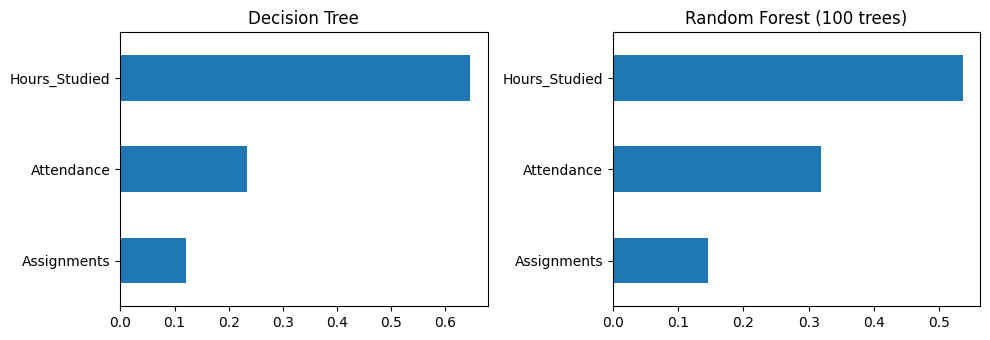

In [10]:
plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
pd.Series(dt.feature_importances_, index=X.columns).sort_values().plot(kind="barh")
plt.title("Decision Tree")

plt.subplot(1, 2, 2)
pd.Series(forests[100].feature_importances_, index=X.columns).sort_values().plot(kind="barh")
plt.title("Random Forest (100 trees)")

plt.tight_layout()
plt.show()

**Conclusion**
A Random Forest trains many trees, each on a random sample of the rows and a random subset of the features, and takes a **majority vote**. A single deep tree is very sensitive to the exact training data (high variance). Because the forest's trees make different mistakes, voting cancels many of them out, so an ensemble usually generalizes better than one tree. Using more trees (10 -> 100 -> 300) mostly makes the result more stable; after a point the accuracy stops improving. In this run the forest also spreads importance more evenly across the features than the single tree, which relies mostly on `Hours_Studied`.

# 3. Class Task 3 - Tune Gradient Boosting

Try `learning_rate` in [0.01, 0.05, 0.1] and `n_estimators` in [50, 100, 200]. The **validation score** is the 5-fold cross-validation accuracy on the training data (the test set stays untouched).

In [11]:
rows = []
for lr in [0.01, 0.05, 0.1]:
    for n_est in [50, 100, 200]:
        gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est, max_depth=3, random_state=42)
        cv_acc = cross_val_score(gb, X_train, y_train, cv=5).mean()
        rows.append([lr, n_est, cv_acc])

gb_table = pd.DataFrame(rows, columns=["learning_rate", "n_estimators", "validation_accuracy"])
gb_table = gb_table.sort_values("validation_accuracy", ascending=False).round(3)
gb_table

,learning_rate,n_estimators,validation_accuracy
1,0.01,100,0.825
6,0.10,50,0.825
2,0.01,200,0.825
4,0.05,100,0.819
3,0.05,50,0.812
7,0.10,100,0.812
5,0.05,200,0.806
8,0.10,200,0.806
0,0.01,50,0.794


In [12]:
best = gb_table.iloc[0]
print("Best validation result: learning_rate =", best["learning_rate"],
      ", n_estimators =", int(best["n_estimators"]), ", accuracy =", best["validation_accuracy"])

best_gb = GradientBoostingClassifier(learning_rate=best["learning_rate"], n_estimators=int(best["n_estimators"]),
                                     max_depth=3, random_state=42).fit(X_train, y_train)
print("Test accuracy of the best model:", round(best_gb.score(X_test, y_test), 3))

Best validation result: learning_rate = 0.01 , n_estimators = 100 , accuracy = 0.825
Test accuracy of the best model: 0.7


**Trade-off: learning rate vs number of estimators**
Each new tree corrects the errors of the previous ones, and `learning_rate` controls how big each correction is.
- **Small learning rate (0.01):** tiny steps, so it needs **many more trees** to reach a good fit. With only 50 trees it underfits. It is slower but usually more stable and less prone to overfitting.
- **Large learning rate (0.1):** big steps, so it fits quickly with fewer trees, but it can overshoot and overfit if too many trees are added.
- So the two settings work together: lowering one means raising the other. The best result is a balance of both, which the table above shows.
- Several combinations score almost the same, and the test accuracy of the best one can differ from its validation accuracy because the dataset is small.

# 4. Class Task 4 - XGBoost Model Tuning

Three combinations of `max_depth` and `learning_rate`:

In [13]:
rows = []
for depth, lr in [(2, 0.1), (4, 0.05), (6, 0.1)]:
    xgb = XGBClassifier(n_estimators=100, max_depth=depth, learning_rate=lr, eval_metric="logloss", random_state=42)
    cv_acc = cross_val_score(xgb, X_train, y_train, cv=5).mean()
    xgb.fit(X_train, y_train)
    rows.append([depth, lr, cv_acc, xgb.score(X_test, y_test)])

xgb_table = pd.DataFrame(rows, columns=["max_depth", "learning_rate", "validation_accuracy", "test_accuracy"])
xgb_table.round(3)

,max_depth,learning_rate,validation_accuracy,test_accuracy
0,2,0.10,0.856,0.750
1,4,0.05,0.850,0.750
2,6,0.10,0.831,0.775


Model comparison on the **same train/test split** (best XGBoost = highest validation accuracy):

In [14]:
best = xgb_table.sort_values("validation_accuracy", ascending=False).iloc[0]
best_xgb = XGBClassifier(n_estimators=100, max_depth=int(best["max_depth"]), learning_rate=best["learning_rate"],
                         eval_metric="logloss", random_state=42).fit(X_train, y_train)

dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42).fit(X_train, y_train)

comparison = pd.DataFrame([
    scores("Decision Tree", dt),
    scores("Random Forest", rf),
    scores("Gradient Boosting", best_gb),
    scores("XGBoost", best_xgb),
]).round(3)
comparison

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.750,0.714,0.789,0.750
1,Random Forest,0.775,0.812,0.684,0.743
2,Gradient Boosting,0.700,0.684,0.684,0.684
3,XGBoost,0.750,0.765,0.684,0.722


# 5. Class Task 5 - XGBoost vs LightGBM

Change `max_depth` for XGBoost and `num_leaves` for LightGBM, and compare the scores and the training time.

In [15]:
rows = []

for depth in [2, 4, 6]:
    model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=depth, eval_metric="logloss", random_state=42)
    start = time.time()
    model.fit(X_train, y_train)
    seconds = time.time() - start
    row = scores("XGBoost", model)
    row.update({"Setting": "max_depth=" + str(depth), "Train time (s)": seconds})
    rows.append(row)

for leaves in [7, 15, 31]:
    model = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=leaves, random_state=42, verbosity=-1)
    start = time.time()
    model.fit(X_train, y_train)
    seconds = time.time() - start
    row = scores("LightGBM", model)
    row.update({"Setting": "num_leaves=" + str(leaves), "Train time (s)": seconds})
    rows.append(row)

pd.DataFrame(rows)[["Model", "Setting", "Accuracy", "Precision", "Recall", "F1", "Train time (s)"]].round(3)

,Model,Setting,Accuracy,Precision,Recall,F1,Train time (s)
0,XGBoost,max_depth=2,0.750,0.765,0.684,0.722,0.087
1,XGBoost,max_depth=4,0.775,0.778,0.737,0.757,0.158
2,XGBoost,max_depth=6,0.775,0.778,0.737,0.757,0.314
3,LightGBM,num_leaves=7,0.775,0.778,0.737,0.757,3.890
4,LightGBM,num_leaves=15,0.775,0.778,0.737,0.757,0.029
5,LightGBM,num_leaves=31,0.775,0.778,0.737,0.757,0.031


**When is an efficient boosting library preferable?**
LightGBM builds trees **leaf-wise** on **histogram-binned** features, so it trains much faster and uses less memory than a level-wise library on **large datasets with many features**. On this tiny dataset all models are fast and the accuracy differences are small, so the speed advantage cannot show. An efficient library is preferable when the data is large, when many experiments or tuning runs are needed, or when training time and memory are limited. The price is that leaf-wise growth can **overfit small datasets**, so `num_leaves` (and `max_depth`) must be controlled; XGBoost's `max_depth` gives more predictable tree sizes.

# 6. Class Task 6 - Mini Kaggle Pipeline (Titanic)
Workflow: load data, inspect, EDA, preprocess, baseline, three tree-based models, validation scores, `submission.csv`.

**Load and inspect**

In [18]:
train = pd.read_csv("Titanic-Dataset.csv")
#test = pd.read_csv("titanic_test.csv")
#print("Train:", train.shape, "| Test:", test.shape)
print("Duplicates:", train.duplicated().sum())
print()
print("Missing values:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print("Class balance (Survived):")
print(train["Survived"].value_counts(normalize=True).round(3))

Duplicates: 0

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Class balance (Survived):
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


**EDA**

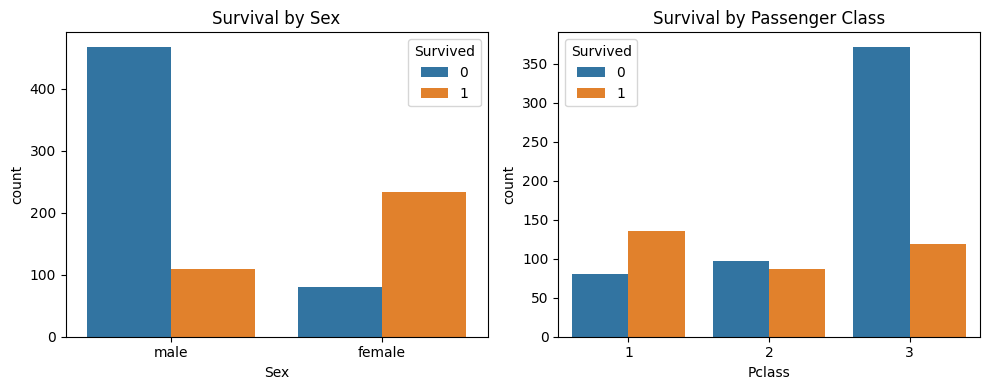

In [19]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x="Sex", hue="Survived", data=train)
plt.title("Survival by Sex")

plt.subplot(1, 2, 2)
sns.countplot(x="Pclass", hue="Survived", data=train)
plt.title("Survival by Passenger Class")

plt.tight_layout()
plt.show()

**Preprocessing** (same function for train and test; fill values come from the training data)

In [21]:
age_median = train["Age"].median()
fare_median = train["Fare"].median()
embarked_mode = train["Embarked"].mode()[0]

def prepare(df):
    df = df.copy()
    df["Age"] = df["Age"].fillna(age_median)
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["Embarked"] = df["Embarked"].fillna(embarked_mode)
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df = pd.get_dummies(df, columns=["Embarked"], dtype=int)
    return df

features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "Embarked_C", "Embarked_Q", "Embarked_S"]
X_titanic = prepare(train)[features]
y_titanic = train["Survived"]
#X_kaggle = prepare(test)[features]

**Baseline and three tree-based models** (validation score = 5-fold cross-validation accuracy)

In [22]:
models = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
}

rows = []
for name, model in models.items():
    cv = cross_val_score(model, X_titanic, y_titanic, cv=5, scoring="accuracy")
    rows.append([name, cv.mean(), cv.std()])

titanic_results = pd.DataFrame(rows, columns=["Model", "Validation accuracy (mean)", "Std"]).round(3)
titanic_results

,Model,Validation accuracy (mean),Std
0,Baseline (most frequent),0.616,0.002
1,Decision Tree,0.807,0.030
2,Random Forest,0.823,0.032
3,Gradient Boosting,0.832,0.020


**Final model and submission**

In [ ]:
best_name = titanic_results.iloc[1:].sort_values("Validation accuracy (mean)", ascending=False).iloc[0]["Model"]
print("Best model:", best_name)

final_model = models[best_name]
final_model.fit(X_titanic, y_titanic)          # train on all labelled data

submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": final_model.predict(X_kaggle)})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

Best model: Gradient Boosting


**Reflection on the competition metric**
Kaggle scores the Titanic competition with **accuracy**: the share of passengers predicted correctly. Here accuracy is reasonable because the classes are only mildly imbalanced (about 62% did not survive, 38% survived), but the baseline that always predicts "did not survive" already scores about 0.62, so a useful model must clearly beat that number. Accuracy treats both kinds of mistakes equally, so precision, recall and F1 would give a fuller picture if one kind of error mattered more. Validation scores from cross-validation are a safer guide than one split, but the final leaderboard score on the hidden test set can still differ a little.

# 7. Final Class Task - Predicting Smartphone Addiction
Pipeline: load, inspect, EDA (3 plots), preprocess, train/validation/test split, five models, compare, choose a final model, feature importance, predictions, report.

**Dataset:** place `smartphone_addiction.csv` next to this notebook. It must contain the columns from the manual (`age`, `daily_screen_time_hours`, ..., `academic_work_impact`) and a **0/1** target column `addicted`.
If the file is missing, the next cell creates a **synthetic stand-in** with the same columns so you can test the notebook. Replace it with the real file for your submission.

In [ ]:
try:
    df = pd.read_csv("smartphone_addiction.csv")
    print("Loaded smartphone_addiction.csv")
except FileNotFoundError:
    print("File not found: using a SYNTHETIC dataset with the same columns (for testing only).")
    rng = np.random.default_rng(42)
    n = 1000
    df = pd.DataFrame({
        "age": rng.integers(15, 50, n),
        "daily_screen_time_hours": rng.normal(6, 2.5, n).clip(1, 16).round(1),
        "social_media_hours": rng.normal(3, 1.5, n).clip(0, 10).round(1),
        "gaming_hours": rng.normal(1.5, 1.2, n).clip(0, 8).round(1),
        "work_study_hours": rng.normal(5, 2, n).clip(0, 12).round(1),
        "sleep_hours": rng.normal(6.5, 1.3, n).clip(3, 10).round(1),
        "notifications_per_day": rng.integers(20, 300, n),
        "app_opens_per_day": rng.integers(10, 150, n),
        "weekend_screen_time": rng.normal(7, 3, n).clip(1, 18).round(1),
        "gender": rng.choice(["Male", "Female", "Other"], n),
        "stress_level": rng.choice(["Low", "Medium", "High"], n),
        "academic_work_impact": rng.choice(["No", "Yes"], n),
    })
    risk = (0.5 * df["daily_screen_time_hours"] + 0.5 * df["social_media_hours"] - 0.5 * df["sleep_hours"]
            + 0.01 * df["notifications_per_day"] + df["stress_level"].map({"Low": 0, "Medium": 1, "High": 2})
            + rng.normal(0, 1.5, n))
    df["addicted"] = (risk > risk.quantile(0.65)).astype(int)
    df.loc[rng.choice(n, 40, replace=False), "sleep_hours"] = np.nan        # a few missing values
    df.loc[rng.choice(n, 30, replace=False), "stress_level"] = np.nan

**Inspect:** shape, columns, data types, missing values, duplicates, target distribution

In [ ]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print()
df.info()
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicates:", df.duplicated().sum())
print()
print("Target distribution:")
print(df["addicted"].value_counts())

**EDA (3 plots)**

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="addicted", data=df)
plt.title("Target distribution")

plt.subplot(1, 3, 2)
sns.boxplot(x="addicted", y="daily_screen_time_hours", data=df)
plt.title("Screen time by addiction")

plt.subplot(1, 3, 3)
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")

plt.tight_layout()
plt.show()

**Preprocessing**
- Missing numeric values -> median, missing text values -> most common value.
- Text columns (`gender`, `stress_level`, `academic_work_impact`) -> one-hot columns with `get_dummies`.
- Split: 60% train, 20% validation (compare models), 20% test (final check, used once).

In [ ]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

text_cols = df.select_dtypes(exclude="number").columns
df = pd.get_dummies(df, columns=text_cols, drop_first=True, dtype=int)

X = df.drop(columns="addicted")
y = df["addicted"]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

**Train the five models and compare them on the validation set** (accuracy, precision, recall, F1, confusion matrix)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42, verbosity=-1),
}

rows = []
plt.figure(figsize=(20, 3.5))
for i, (name, model) in enumerate(models.items(), start=1):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_val, pred),
                 "Precision": precision_score(y_val, pred),
                 "Recall": recall_score(y_val, pred),
                 "F1": f1_score(y_val, pred)})
    plt.subplot(1, 5, i)
    sns.heatmap(confusion_matrix(y_val, pred), annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame(rows).sort_values("F1", ascending=False).round(3)
comparison

**Select the final model** (highest validation F1, because the addicted class is the minority and both missed cases and false alarms matter), then check it once on the test set.

In [ ]:
final_name = comparison.iloc[0]["Model"]
final_model = models[final_name]
print("Final model:", final_name)

test_pred = final_model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, test_pred), 3))
print(classification_report(y_test, test_pred))

**Feature importance**

In [ ]:
importance = pd.Series(final_model.feature_importances_, index=X.columns).sort_values()
importance.plot(kind="barh", figsize=(8, 5))
plt.title("Feature importance - " + final_name)
plt.show()

**Predictions for the test data** (saved to a file)

In [ ]:
output = X_test.copy()
output["actual"] = y_test
output["predicted"] = test_pred
output.to_csv("smartphone_predictions.csv", index=False)
output.head()

**If a separate unseen test file is provided:** load it, apply the same preprocessing (same fill rules and `get_dummies`), keep the same column order as `X.columns`, then call `final_model.predict(...)`.

## Short Report

**Problem statement:** predict whether a person is addicted to smartphone use (binary classification) from behavioural and demographic attributes.

**Preprocessing:** missing values filled (median / most common value), text columns one-hot encoded, data split 60/20/20 into train, validation and test with the class ratio preserved.

**Model comparison:** Decision Tree, Random Forest, Gradient Boosting, XGBoost and LightGBM were compared on the validation set using accuracy, precision, recall, F1 and confusion matrices (table and plots above).

**Results and observations:** the final model is the one with the highest validation F1; its test results and feature importances are shown above. Ensemble models normally beat the single Decision Tree. The top-ranked features show which behaviours matter most for addiction.

**Limitations:** the data may be self-reported and not representative; hyperparameters were not tuned extensively; the data is a single snapshot, so the model shows association, not cause; a single validation split can be noisy.

**Final conclusion:** the selected model is a reasonable predictor of smartphone addiction, but it should be validated on new data (and tuned with cross-validation) before being relied on.

In [ ]:
print("Final model:", final_name)
print("Validation F1:", comparison.iloc[0]["F1"])
print("Test accuracy:", round(accuracy_score(y_test, test_pred), 3))
print("Most important feature:", importance.idxmax())